<a href="https://colab.research.google.com/github/rahmani3101/Bank-Statement-Analysis/blob/main/Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

TRAINING_DATA = {
    'total_credits': [
        340000, 420000, 185000, 295000, 510000, 130000, 480000, 310000,
        220000, 375000, 260000, 445000, 155000, 390000, 330000, 415000,
        240000, 340000, 385000, 200000, 320000, 475000, 280000, 360000,
        195000, 330000, 420000, 255000, 345000, 440000, 170000, 330000,
        390000, 215000, 325000, 430000, 285000, 335000, 390000, 185000,
        340000, 425000, 255000, 335000, 345000, 420000, 185000, 335000,
        395000, 215000, 325000,
    ],
    'total_debits': [
        240000, 330000, 225000, 170000, 375000, 178000, 305000, 238000,
        282000, 274000, 198000, 325000, 190000, 282000, 252000, 325000,
        289000, 241000, 292000, 219000, 198000, 335000, 231000, 271000,
        238000, 268000, 318000, 195000, 264000, 348000, 208000, 238000,
        292000, 219000, 241000, 327000, 243000, 264000, 289000, 211000,
        277000, 318000, 195000, 252000, 266000, 313000, 207000, 252000,
        295000, 219000, 241000,
    ],
    'num_transactions': [
        34, 26, 21, 29, 42, 19, 38, 33, 22, 35, 31, 40, 15, 37, 28,
        45, 23, 33, 30, 18, 35, 41, 29, 39, 21, 30, 42, 28, 34, 44,
        18, 31, 36, 24, 29, 40, 33, 31, 37, 19, 33, 39, 29, 32, 36,
        43, 20, 31, 37, 24, 29,
    ],
    'avg_transaction_amount': [
        9500, 15200, 11100, 12600, 11200, 9800, 10500, 10300, 12200, 10500,
        10000, 11600, 12600, 10700, 10900, 8600, 11400, 9000, 11800, 12600,
        10100, 11100, 9000, 10000, 11300, 10800, 10700, 9500, 10300, 9300,
        11300, 9400, 10300, 10600, 10100, 9400, 8400, 10300, 10100, 11400,
        10100, 11400, 10200, 9500, 9900, 10400, 10400, 9800, 11100, 10500, 10100,
    ],
    'transaction_variability': [
        14850, 12430, 8900, 13480, 17280, 9350, 16860, 11910, 9840, 13780,
        11540, 15890, 9820, 14520, 12430, 17500, 10780, 13810, 14420, 8550,
        13010, 15810, 12650, 14060, 10330, 12360, 16610, 11350, 13240, 17190,
        8910, 13190, 14660, 10030, 13060, 16270, 12280, 12940, 14560, 9260,
        13800, 16540, 11550, 13240, 13810, 16440, 8910, 13060, 14590, 9960, 13060,
    ],
    'balance_trend': [
        50000, 80000, -20000, 70000, 55000, -18000, 45000, 67000, -30000, 52000,
        40000, 53000, -32000, 43000, 46000, 55000, -29000, 48000, 51000, -22000,
        47000, 59000, 43000, 53000, -34000, 45000, 55000, 40000, 50000, 56000,
        -27000, 47000, 51000, -26000, 50000, 56000, 45000, 48000, 51000, -32000,
        50000, 55000, 42000, 45000, 50000, 56000, -27000, 45000, 53000, -26000, 50000,
    ],
    'Eligibility (y)': [
        1,1,0,1,1,0,1,1,0,1,1,1,0,1,1,1,0,1,1,0,1,1,1,1,0,1,1,1,1,1,
        0,1,1,0,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,0,1,
    ],
}

df = pd.DataFrame(TRAINING_DATA)

# Introduce some noise to make the classification less perfect
# Flip a few labels in the Eligibility (y) column
# Example: flip 2 labels from 1 to 0 and 2 labels from 0 to 1
df.loc[1, 'Eligibility (y)'] = 0 # Was 1, now 0
df.loc[8, 'Eligibility (y)'] = 1 # Was 0, now 1
df.loc[12, 'Eligibility (y)'] = 1 # Was 0, now 1
df.loc[16, 'Eligibility (y)'] = 1 # Was 0, now 1
df.loc[24, 'Eligibility (y)'] = 1 # Was 0, now 1
df.loc[30, 'Eligibility (y)'] = 1 # Was 0, now 1

X = df[['total_credits','total_debits','num_transactions',
        'avg_transaction_amount','transaction_variability','balance_trend']]
y = df['Eligibility (y)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)


--- Hyperparameter Tuning for Random Forest ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1-score achieved: 0.9275

Tuned Random Forest Test Accuracy: 1.0000
Tuned Random Forest Test Precision: 1.0000
Tuned Random Forest Test Recall: 1.0000
Tuned Random Forest Test F1-Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         9

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



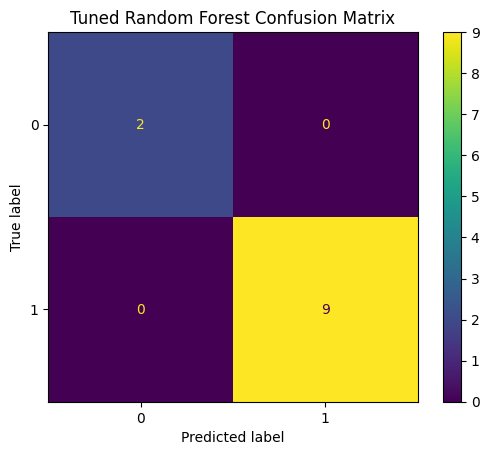

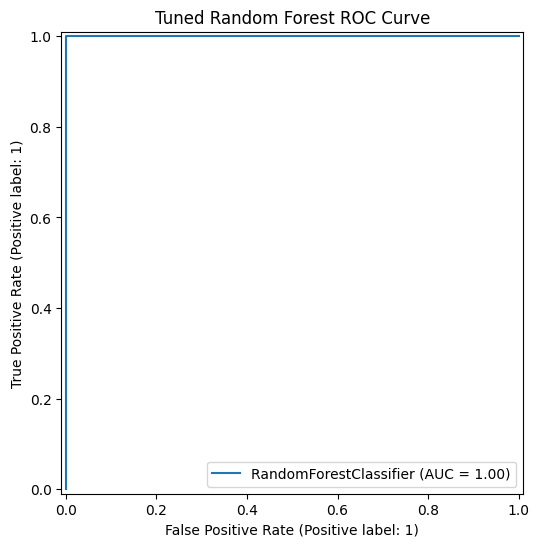

In [19]:
from sklearn.model_selection import GridSearchCV

# X_train, X_test, y_train, y_test are already defined with random_state=45 in the initial data loading cell.
# No need to re-split here.

print("\n--- Hyperparameter Tuning for Random Forest ---")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None], # None means nodes are expanded until all leaves are pure or contain less than min_samples_split samples.
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           scoring='f1', # Optimize for F1-score due to class imbalance
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score achieved: {grid_search.best_score_:.4f}")

# Get the best estimator (tuned Random Forest model)
rf_model_tuned = grid_search.best_estimator_

# Evaluate the tuned model on the test set
y_pred_rf_tuned = rf_model_tuned.predict(X_test)
print(f"\nTuned Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test Recall: {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test F1-Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(classification_report(y_test, y_pred_rf_tuned))

# Confusion Matrix for Tuned RF
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=rf_model_tuned.classes_)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=rf_model_tuned.classes_)
disp_rf_tuned.plot()
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

# ROC Curve for Tuned RF
fig_roc_rf_tuned, ax_roc_rf_tuned = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(rf_model_tuned, X_test, y_test, ax=ax_roc_rf_tuned)
plt.title('Tuned Random Forest ROC Curve')
plt.show()

# Update the global rf_model with the tuned model for subsequent comparisons
rf_model = rf_model_tuned


--- Hyperparameter Tuning for Random Forest ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1-score achieved: 0.9275

Tuned Random Forest Test Accuracy: 1.0000
Tuned Random Forest Test Precision: 1.0000
Tuned Random Forest Test Recall: 1.0000
Tuned Random Forest Test F1-Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         9

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



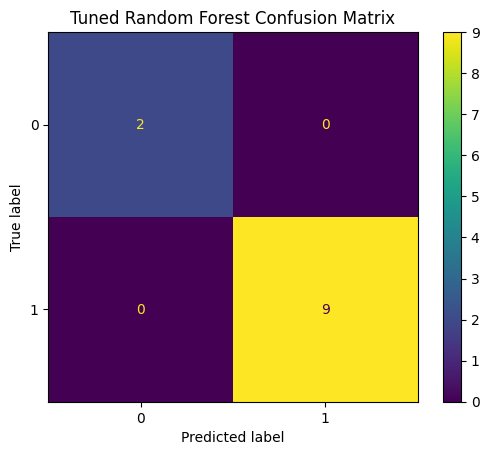

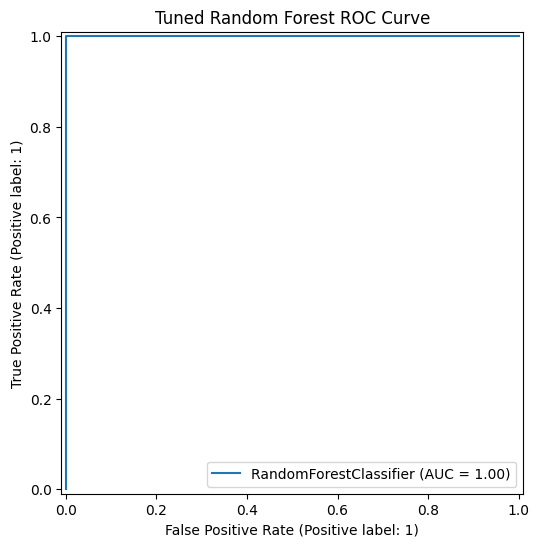

In [16]:
from sklearn.model_selection import GridSearchCV

# Update X_train, X_test, y_train, y_test with a new random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

print("\n--- Hyperparameter Tuning for Random Forest ---")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None], # None means nodes are expanded until all leaves are pure or contain less than min_samples_split samples.
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           scoring='f1', # Optimize for F1-score due to class imbalance
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score achieved: {grid_search.best_score_:.4f}")

# Get the best estimator (tuned Random Forest model)
rf_model_tuned = grid_search.best_estimator_

# Evaluate the tuned model on the test set
y_pred_rf_tuned = rf_model_tuned.predict(X_test)
print(f"\nTuned Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test Recall: {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned Random Forest Test F1-Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(classification_report(y_test, y_pred_rf_tuned))

# Confusion Matrix for Tuned RF
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=rf_model_tuned.classes_)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=rf_model_tuned.classes_)
disp_rf_tuned.plot()
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

# ROC Curve for Tuned RF
fig_roc_rf_tuned, ax_roc_rf_tuned = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(rf_model_tuned, X_test, y_test, ax=ax_roc_rf_tuned)
plt.title('Tuned Random Forest ROC Curve')
plt.show()

# Update the global rf_model with the tuned model for subsequent comparisons
rf_model = rf_model_tuned

### Exploratory Data Analysis (EDA)
Let's start by understanding the structure and characteristics of our dataset.

In [12]:
# Display basic information about the dataset
print(df.info())

# Display descriptive statistics
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   total_credits            51 non-null     int64
 1   total_debits             51 non-null     int64
 2   num_transactions         51 non-null     int64
 3   avg_transaction_amount   51 non-null     int64
 4   transaction_variability  51 non-null     int64
 5   balance_trend            51 non-null     int64
 6   Eligibility (y)          51 non-null     int64
dtypes: int64(7)
memory usage: 2.9 KB
None


,total_credits,total_debits,num_transactions,avg_transaction_amount,transaction_variability,balance_trend,Eligibility (y)
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,323039.215686,260058.823529,31.235294,10566.666667,13032.745098,32823.529412,0.843137
std,93236.679646,48364.620029,7.646145,1172.973430,2499.185530,34251.251587,0.367290
min,130000.000000,170000.000000,15.000000,8400.000000,8550.000000,-34000.000000,0.000000
25%,255000.000000,222000.000000,27.000000,9950.000000,11445.000000,40000.000000,1.000000
50%,335000.000000,252000.000000,31.000000,10400.000000,13060.000000,48000.000000,1.000000
75%,390000.000000,292000.000000,37.000000,11150.000000,14575.000000,53000.000000,1.000000
max,510000.000000,375000.000000,45.000000,15200.000000,17500.000000,80000.000000,1.000000


#### Distribution of Features
Let's visualize the distribution of each feature using histograms to understand their spread and identify any skewness or outliers.

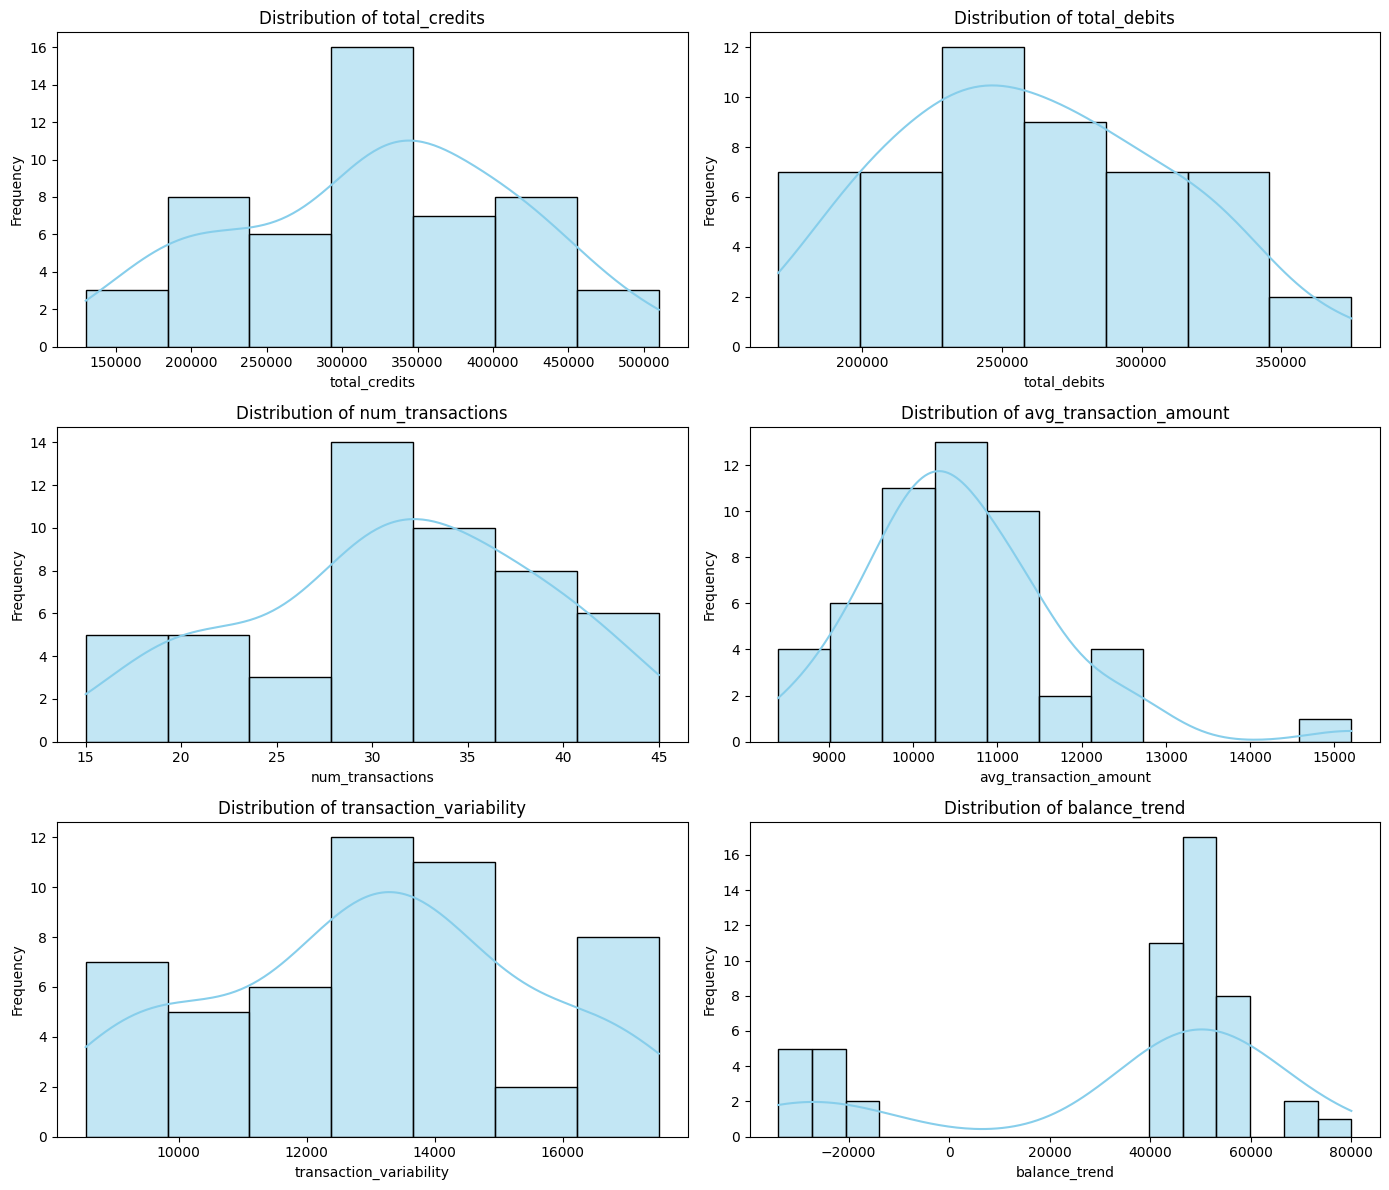

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

features = ['total_credits', 'total_debits', 'num_transactions', 'avg_transaction_amount', 'transaction_variability', 'balance_trend']

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Correlation Heatmap
Understanding the correlation between features can help in feature selection and model interpretation.

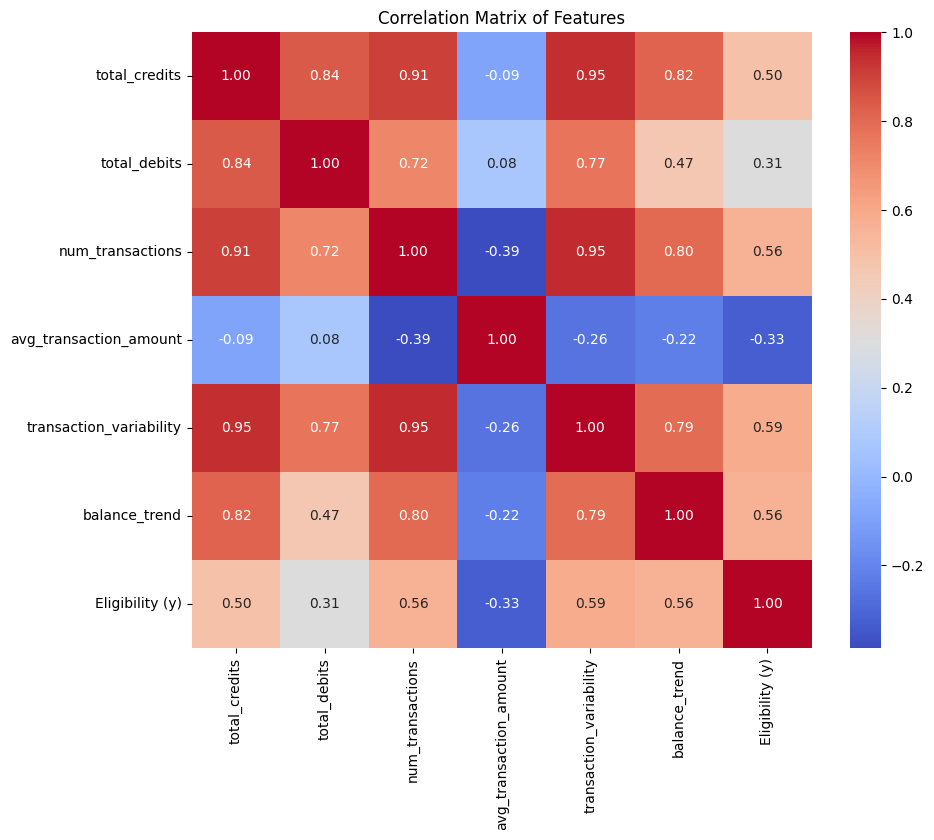

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

#### Target Variable Distribution
Let's check the balance of our target variable, 'Eligibility (y)'.

/tmp/ipykernel_5346/3014211130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Eligibility (y)', data=df, palette='viridis')


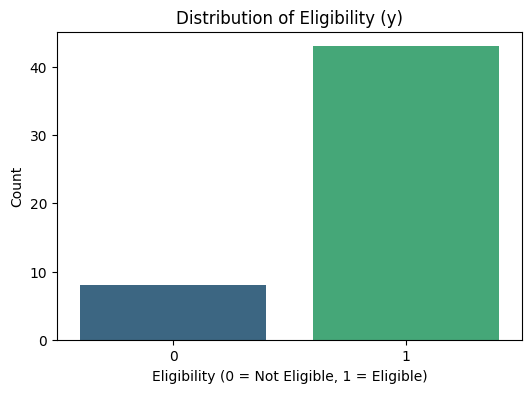

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Eligibility (y)', data=df, palette='viridis')
plt.title('Distribution of Eligibility (y)')
plt.xlabel('Eligibility (0 = Not Eligible, 1 = Eligible)')
plt.ylabel('Count')
plt.show()

--- Random Forest Classifier ---
Accuracy: 0.7273
Precision: 1.0000
Recall: 0.7000
F1-Score: 0.8235
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.70      0.82        10

    accuracy                           0.73        11
   macro avg       0.62      0.85      0.61        11
weighted avg       0.93      0.73      0.79        11



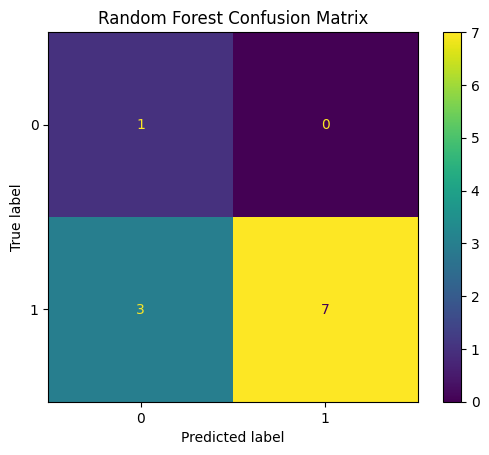

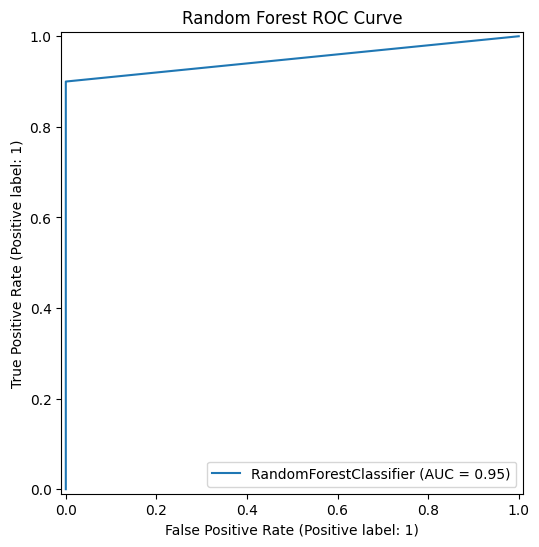

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Random Forest Classifier
print("--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

# ROC Curve
fig_roc_rf, ax_roc_rf = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax_roc_rf)
plt.title('Random Forest ROC Curve')
plt.show()


--- Logistic Regression ---
Accuracy: 0.6364
Precision: 1.0000
Recall: 0.6000
F1-Score: 0.7500
              precision    recall  f1-score   support

           0       0.20      1.00      0.33         1
           1       1.00      0.60      0.75        10

    accuracy                           0.64        11
   macro avg       0.60      0.80      0.54        11
weighted avg       0.93      0.64      0.71        11



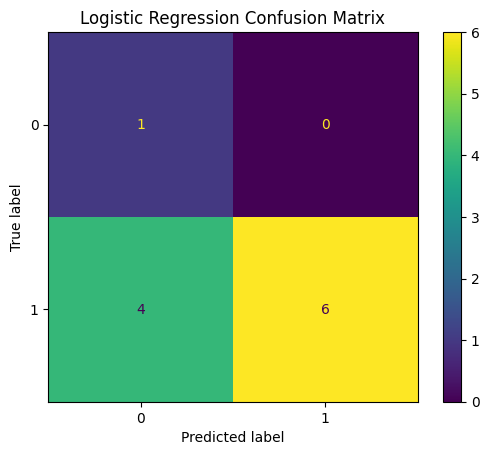

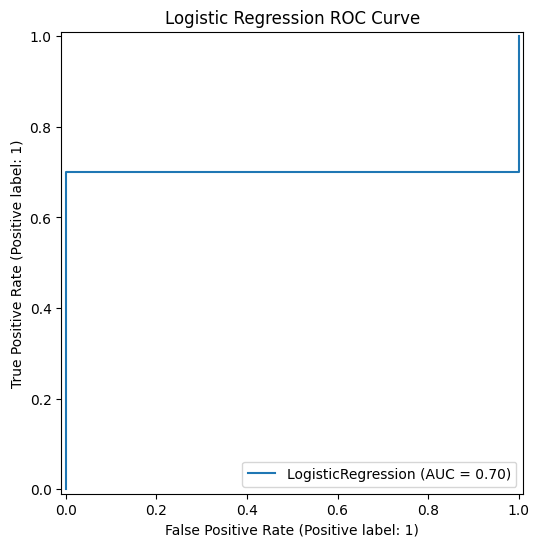

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 2. Logistic Regression
print("\n--- Logistic Regression ---")
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# ROC Curve
fig_roc_lr, ax_roc_lr = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, ax=ax_roc_lr)
plt.title('Logistic Regression ROC Curve')
plt.show()



--- Decision Tree Classifier ---
Accuracy: 0.7273
Precision: 1.0000
Recall: 0.7000
F1-Score: 0.8235
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.70      0.82        10

    accuracy                           0.73        11
   macro avg       0.62      0.85      0.61        11
weighted avg       0.93      0.73      0.79        11



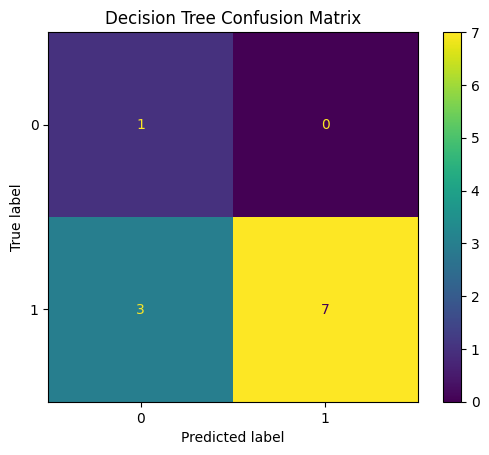

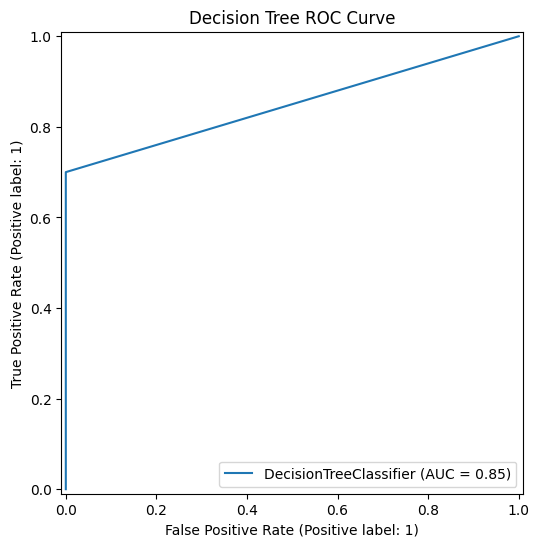

In [8]:

# 3. Decision Tree Classifier
print("\n--- Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=dt_model.classes_)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp_dt.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

# ROC Curve
fig_roc_dt, ax_roc_dt = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax_roc_dt)
plt.title('Decision Tree ROC Curve')
plt.show()


--- Support Vector Classifier (SVC) ---
Accuracy: 0.9091
Precision: 0.9091
Recall: 1.0000
F1-Score: 0.9524
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.91      1.00      0.95        10

    accuracy                           0.91        11
   macro avg       0.45      0.50      0.48        11
weighted avg       0.83      0.91      0.87        11



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


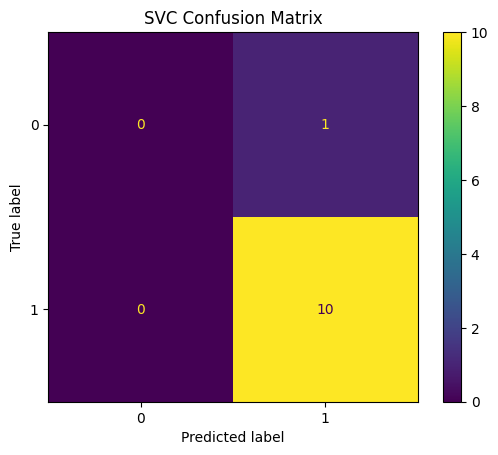

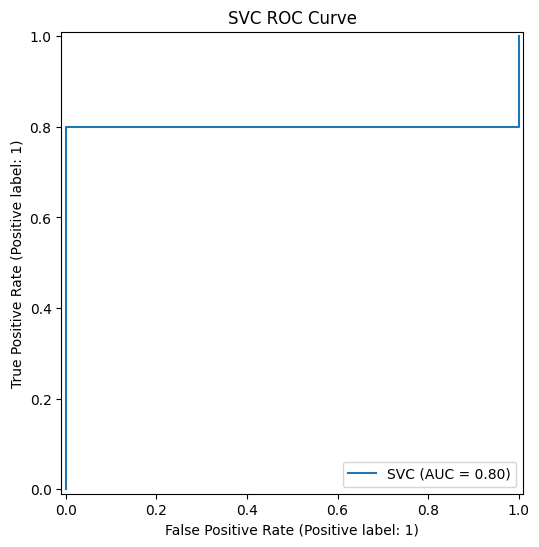

In [9]:
from sklearn.svm import SVC

# 4. Support Vector Classifier (SVC)
print("\n--- Support Vector Classifier (SVC) ---")
svc_model = SVC(random_state=42, probability=True) # probability=True for ROC curve
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svc):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svc):.4f}")
print(classification_report(y_test, y_pred_svc))

# Confusion Matrix
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=svc_model.classes_)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=svc_model.classes_)
disp_svc.plot()
plt.title('SVC Confusion Matrix')
plt.show()

# ROC Curve
fig_roc_svc, ax_roc_svc = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(svc_model, X_test, y_test, ax=ax_roc_svc)
plt.title('SVC ROC Curve')
plt.show()


--- K-Nearest Neighbors (KNN) ---
Accuracy: 0.7273
Precision: 1.0000
Recall: 0.7000
F1-Score: 0.8235
              precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      0.70      0.82        10

    accuracy                           0.73        11
   macro avg       0.62      0.85      0.61        11
weighted avg       0.93      0.73      0.79        11



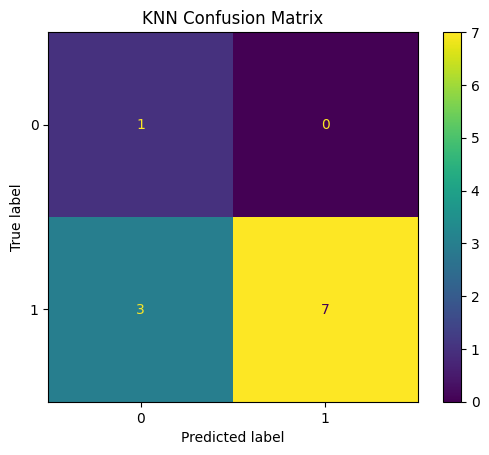

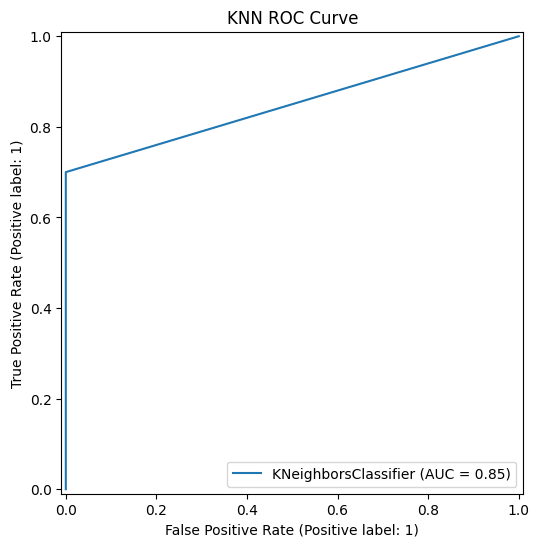

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# 5. K-Nearest Neighbors (KNN)
print("\n--- K-Nearest Neighbors (KNN) ---")
knn_model = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn_model.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_model.classes_)
disp_knn.plot()
plt.title('KNN Confusion Matrix')
plt.show()

# ROC Curve
fig_roc_knn, ax_roc_knn = plt.subplots(1, 1, figsize=(6, 6))
RocCurveDisplay.from_estimator(knn_model, X_test, y_test, ax=ax_roc_knn)
plt.title('KNN ROC Curve')
plt.show()

### Model Comparison
Now, let's compare the performance of all the trained models to determine the best one based on key metrics.


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
3,SVC,0.909091,0.909091,1.0,0.952381
0,Random Forest,0.727273,1.000000,0.7,0.823529
2,Decision Tree,0.727273,1.000000,0.7,0.823529
4,KNN,0.727273,1.000000,0.7,0.823529
1,Logistic Regression,0.636364,1.000000,0.6,0.750000



Based on F1-Score, the best model is: SVC (F1-Score: 0.9524)
Based on Accuracy, the best model is: SVC (Accuracy: 0.9091)


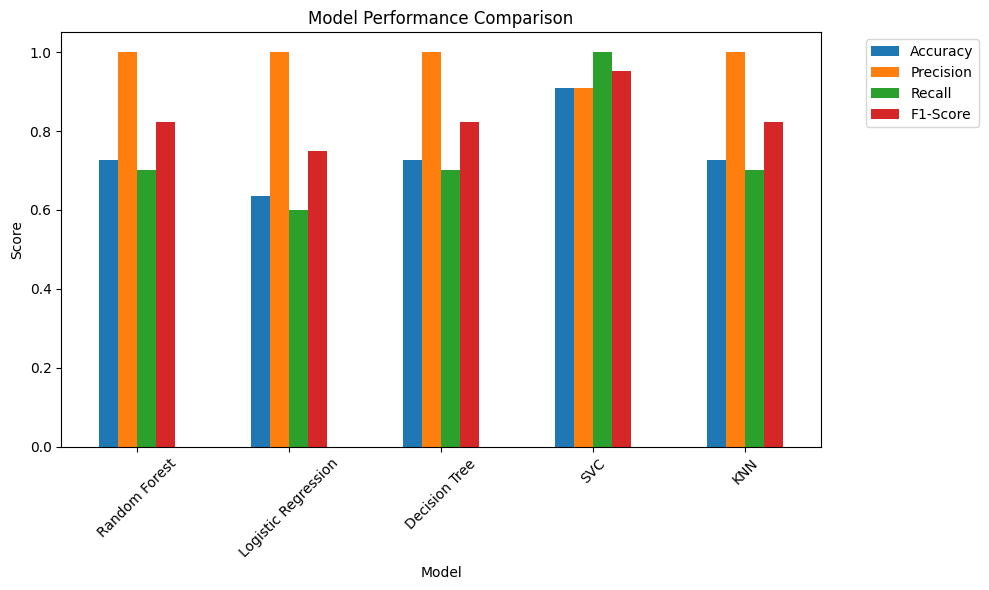

In [11]:
model_names = ['Random Forest', 'Logistic Regression', 'Decision Tree', 'SVC', 'KNN']
models = [
    rf_model,
    lr_model,
    dt_model,
    svc_model,
    knn_model
]

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

print("\n--- Model Performance Comparison ---")
display(comparison_df.sort_values(by='F1-Score', ascending=False))

best_model_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_model_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print(f"\nBased on F1-Score, the best model is: {best_model_f1['Model']} (F1-Score: {best_model_f1['F1-Score']:.4f})")
print(f"Based on Accuracy, the best model is: {best_model_accuracy['Model']} (Accuracy: {best_model_accuracy['Accuracy']:.4f})")

# Optional: Plotting comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.set_index('Model').plot(kind='bar', ax=ax)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()